In [2]:
import rasterio
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

In [4]:
# 125 meters resolution
# tif_path = '/home/kim/data/modis/moa125_2014_hp1_v01.tif'
# 750
tif_path = '/home/kim/data/modis/moa750_2014_hp1_v01.tif.1'

# The hr image takes a while to load... (7 minutes)
with rasterio.open(tif_path) as src:
    # Read the data (for single-band TIFs, read the first band)
    image = src.read(1) 

# Replace 0 values with NaN for better visualization
image_na = image.copy().astype(float)
image_na[image_na == 0.0] = np.nan

In [6]:
image_na.shape

(6964, 8056)

In [7]:
def convert_polarstero_to_modis_indices(ps_x_min, ps_x_max, ps_y_min, ps_y_max, spacing = 750):
    # x
    x_min = int((3174450 - - ps_x_min) / spacing)
    x_max = int((3174450 - - ps_x_max) / spacing)
    # y 
    y_max = int((2406325 - ps_y_min) / spacing)
    y_min = int((2406325 - ps_y_max) / spacing)
    
    return x_min, x_max, y_min, y_max

In [10]:
# define domain coordinates in Polar Stereographic projection: 200 x 200 km square
byrd_catchment_x_min = 350 * 1000
byrd_catchment_x_max = 600 * 1000
byrd_catchment_y_min = - 700 * 1000
byrd_catchment_y_max = - 950 * 1000

x_min, x_max, y_min, y_max = convert_polarstero_to_modis_indices(
    byrd_catchment_x_min,
    byrd_catchment_x_max,
    byrd_catchment_y_min,
    byrd_catchment_y_max,
    spacing = 750
)

print(x_min, x_max, y_min, y_max)

4699 5032 4475 4141


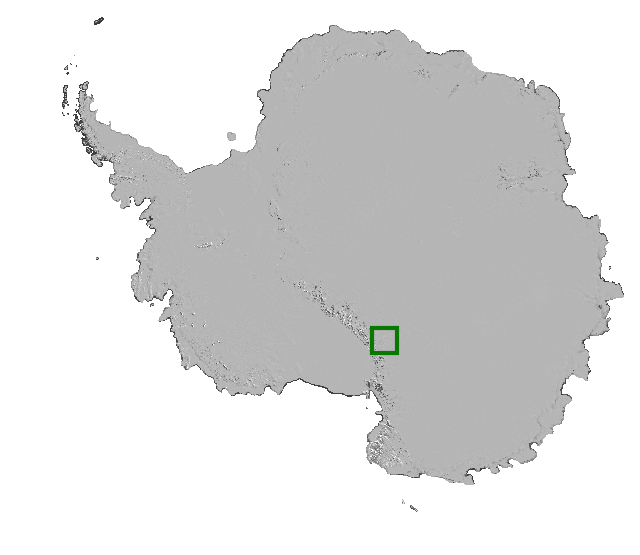

In [11]:
# Takes around 20 seconds
plt.figure(figsize = (8, 8))
# Same settings as other vis
plt.pcolormesh(image_na, vmin = 0, vmax = 25_000, cmap = "gray", alpha = 0.8) 

rect = patches.Rectangle(
    (x_min, y_min),   # (x, y) lower left corner
    x_max - x_min,    # width (latitude span)
    y_max - y_min,    # height
    linewidth = 3,
    edgecolor = '#087801',
    facecolor = 'none'  # transparent fill
)

# Add to current axes
plt.gca().add_patch(rect)
plt.gca().invert_yaxis()
plt.gca().set_aspect('equal', adjustable = 'box')

# Remove coordinate system (axes)
plt.axis('off')

# Save the figure to file
plt.savefig('modis_with_rectangle.png', dpi = 300, bbox_inches = 'tight', pad_inches = 0)

plt.show()